In [17]:
print("Hello World!")

Hello World!


In [18]:
from lerobot.datasets.lerobot_dataset import LeRobotDataset

dataset = LeRobotDataset(
    repo_id="lerobot/libero_spatial_image",
    root="../datasets/libero_spatial_image"  # wherever you downloaded it
)

In [19]:
print(len(dataset))
print(dataset[0].keys())

52970
dict_keys(['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task'])


In [20]:
print(dataset.meta.features["observation.state"])

{'dtype': 'float32', 'shape': (8,), 'names': {'motors': ['x', 'y', 'z', 'rx', 'ry', 'rz', 'rw', 'gripper']}, 'fps': 10}


In [21]:
sample = dataset[100]

print(sample["observation.images.image"].shape)

torch.Size([3, 256, 256])


In [22]:
print(sample["task"])

pick up the black bowl next to the cookie box and place it on the plate


torch.Size([3, 256, 256])


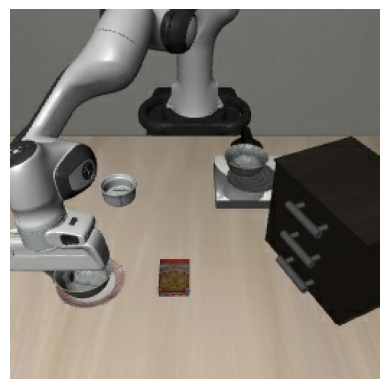

In [23]:
import matplotlib.pyplot as plt
image = sample["observation.images.image"]
print(image.shape)
image = image.detach().cpu()

if image.shape[0] in [1, 3, 4]:
    image = image.permute(1, 2, 0)


image = image.numpy()
plt.imshow(image)
plt.axis("off")
plt.show()

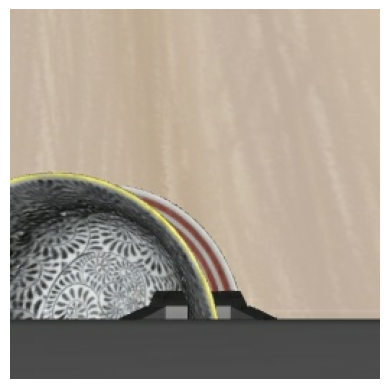

In [24]:
image = sample["observation.images.wrist_image"]
image = image.detach().cpu()

if image.shape[0] in [1, 3, 4]:
    image = image.permute(1, 2, 0)


image = image.numpy()
plt.imshow(image)
plt.axis("off")
plt.show()

In [25]:
print(sample["observation.state"])

tensor([ 7.9094e-02,  2.5739e-01,  9.3285e-01,  3.0107e+00,  1.6530e-01,
         1.3407e-01,  2.6739e-03, -5.0590e-03])


In [26]:
print(sample["action"])

tensor([ 0.0000, -0.0509, -0.3964,  0.0279,  0.0707, -0.0589,  1.0000])


In [27]:
delta_timestamps = {
        "action": [i / 10.0 for i in range(50)],  # fps=10 for LIBERO
    }
dataset = LeRobotDataset(
        repo_id="lerobot/libero_spatial_image",
        root="../datasets/libero_spatial_image",
        delta_timestamps=delta_timestamps,
    )

In [39]:
sample = dataset[0]

print(sample["observation.images.image"].shape)

torch.Size([3, 256, 256])


In [40]:
print(sample["task"])

pick up the black bowl next to the cookie box and place it on the plate


In [ ]:
print(sample["observation.state"])

#tensor([-0.2108, -0.0152,  1.1757,  3.1512, -0.0839, -0.0712,  0.0208, -0.0208],

tensor([-2.0487e-01, -1.0082e-02,  1.1747e+00,  3.1396e+00,  1.4412e-04,
        -8.8018e-02,  3.8786e-02, -3.8790e-02])


In [31]:
print(sample["action"].shape)

torch.Size([50, 7])


In [32]:
import torch

checkpoint = torch.load('../checkpoints/checkpoint_epoch2.pt', map_location='cuda', weights_only=False)
print(type(checkpoint))

<class 'collections.OrderedDict'>
